

# ROC Curve and ROC-AUC

## Why Do We Need ROC Curves?

Most classification models, such as Logistic Regression, do not directly predict a class label. Instead, they output a probability between **0 and 1**.

For example:

```text
P(Class = 1) = 0.85
```

To convert this probability into a class prediction, we choose a **threshold**.

Commonly:

```text
Probability ≥ 0.5 → Class 1
Probability < 0.5 → Class 0
```

However, changing the threshold changes the model's behavior.

* Lower threshold → More positive predictions.
* Higher threshold → More conservative predictions.

The challenge is deciding which threshold gives the best balance between correctly identifying positives and avoiding false alarms.

This is where the **ROC Curve** becomes useful.

---

## Confusion Matrix

The confusion matrix breaks predictions into four categories:

| Actual   | Predicted | Result              |
| -------- | --------- | ------------------- |
| Positive | Positive  | True Positive (TP)  |
| Positive | Negative  | False Negative (FN) |
| Negative | Positive  | False Positive (FP) |
| Negative | Negative  | True Negative (TN)  |

These four values form the foundation of ROC analysis.

---

## True Positive Rate (TPR)

Also known as **Recall** or **Sensitivity**.

Measures how many actual positive cases are correctly identified.

$$TPR = \frac{TP}{TP + FN}$$

### Intuition

Out of all actual positive cases:

```text
How many did the model correctly catch?
```

Higher TPR is better.

---

## False Positive Rate (FPR)

Measures how many actual negative cases are incorrectly classified as positive.

$$FPR = \frac{FP}{FP + TN}$$

### Intuition

Out of all actual negative cases:

```text
How many were incorrectly flagged as positive?
```

Lower FPR is better.

---

## ROC Curve

ROC stands for:

```text
Receiver Operating Characteristic
```

It is a graph of:

```text
Y-axis → True Positive Rate (TPR)
X-axis → False Positive Rate (FPR)
```

for different threshold values.

---

## How Threshold Affects the Curve

### Lower Threshold

Example:

```text
Threshold = 0.2
```

The model predicts positive more frequently.

Result:

* Higher TPR
* Higher FPR

You catch more positives but also create more false alarms.

---

### Higher Threshold

Example:

```text
Threshold = 0.9
```

The model becomes very strict.

Result:

* Lower TPR
* Lower FPR

Fewer false alarms but also more missed positives.

---

## Ideal ROC Curve

The best possible point is:

[
TPR = 1
]

and

[
FPR = 0
]

which corresponds to the **top-left corner** of the graph.

This means:

* Every positive is detected.
* No negative is incorrectly classified.

---

## Understanding ROC-AUC

AUC stands for:

```text
Area Under the Curve
```

Instead of analyzing the entire ROC curve visually, we calculate the area underneath it.

This gives a single number representing model performance across all thresholds.

---

## Interpreting AUC

### Perfect Model

[
AUC = 1.0
]

The model perfectly separates both classes.

---

### Random Guessing

[
AUC = 0.5
]

The model performs no better than flipping a coin.

---

### Practical Interpretation

```text
Higher AUC = Better overall classification performance
```

AUC is especially useful when comparing multiple classification models.

Example:

```text
Logistic Regression → AUC = 0.89
SVM → AUC = 0.93
```

In this case, the SVM performs better overall.

---

## Main Intuition

ROC Curve helps us understand how a model behaves at different classification thresholds.

Instead of evaluating the model at a single threshold (like 0.5), ROC evaluates performance across all possible thresholds.

The goal is:

* Maximize True Positive Rate (Benefit)
* Minimize False Positive Rate (Cost)

ROC-AUC summarizes this trade-off into a single number, making it one of the most important metrics for evaluating binary classification models.

For this notebook, focus more on the **intuition behind thresholds, TPR, FPR, and AUC** rather than memorizing formulas. The visualizations are the most important part of understanding ROC curves.


In [1]:
import pandas as pd

data = pd.read_csv('https://raw.githubusercontent.com/npradaschnor/Pima-Indians-Diabetes-Dataset/master/diabetes.csv')

data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [2]:
X = data.drop('Outcome', axis=1)
y = data['Outcome']

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [4]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [5]:
y_scores = model.predict_proba(X_test)[:,1]

In [7]:
# these are the probabilties of each value 
y_scores

array([0.04953733, 0.17458572, 0.09362456, 0.25509799, 0.63549866,
       0.11671342, 0.0656711 , 0.42190291, 0.04865986, 0.57564059,
       0.33874547, 0.41302642, 0.69854328, 0.19964289, 0.02001673,
       0.82469232, 0.86657235, 0.03101174, 0.25510351, 0.89492586,
       0.95245469, 0.83478059, 0.11740826, 0.44671151, 0.08923333,
       0.06882382, 0.65117465, 0.41197534, 0.17861637, 0.28689796,
       0.24548259, 0.43902276, 0.00942493, 0.24259587, 0.35168787,
       0.96164424, 0.34360335, 0.80924392, 0.29380564, 0.05083276,
       0.18184936, 0.08672257, 0.42229258, 0.18738304, 0.03011666,
       0.03949289, 0.24741169, 0.42782804, 0.10529543, 0.37970365,
       0.99355844, 0.10667497, 0.39101794, 0.76881525, 0.36866093,
       0.45775299, 0.95035242, 0.419917  , 0.39155685, 0.04376147,
       0.37293202, 0.90128061, 0.88176116, 0.88842638, 0.33084208,
       0.06931589, 0.95264364, 0.20056037, 0.26055172, 0.3546289 ,
       0.10358944, 0.08168612, 0.4504401 , 0.09221315, 0.08648

In [8]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_scores)

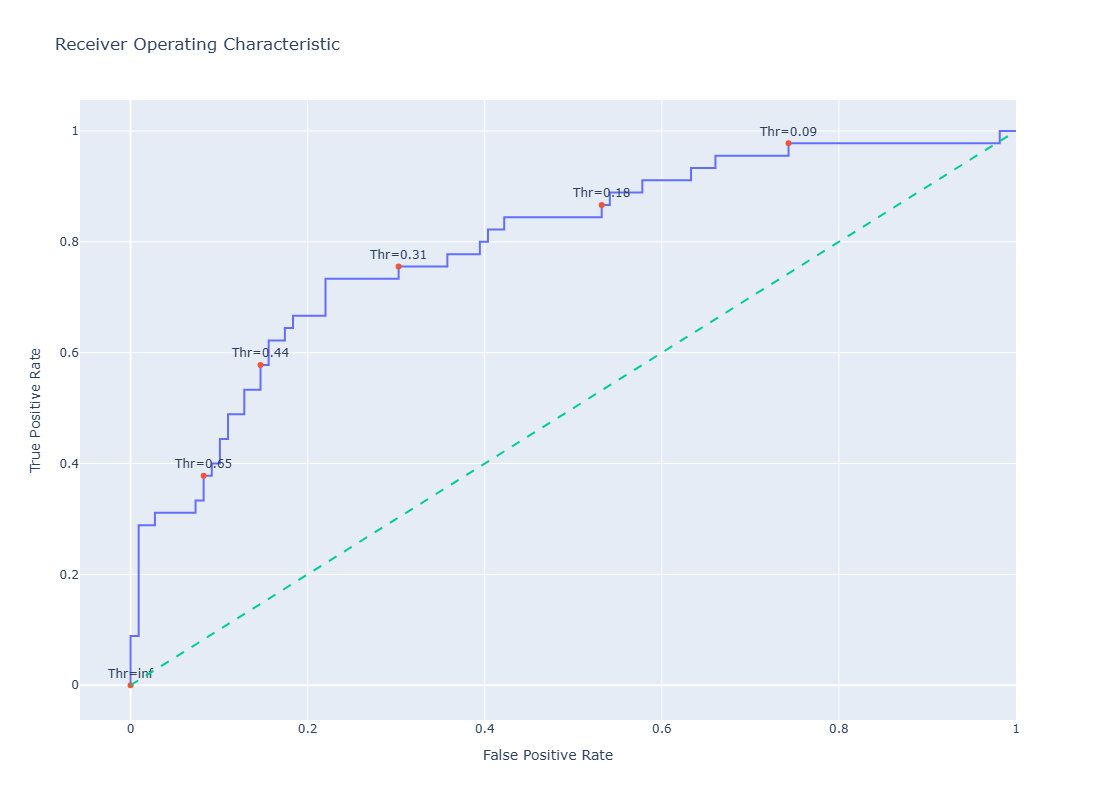

In [9]:
import plotly.graph_objects as go
import numpy as np


# Generate a trace for ROC curve
trace0 = go.Scatter(
    x=fpr,
    y=tpr,
    mode='lines',
    name='ROC curve'
)

# Only label every nth point to avoid cluttering
n = 10
indices = np.arange(len(thresholds)) % n == 0  # Choose indices where index mod n is 0

trace1 = go.Scatter(
    x=fpr[indices],
    y=tpr[indices],
    mode='markers+text',
    name='Threshold points',
    text=[f"Thr={thr:.2f}" for thr in thresholds[indices]],
    textposition='top center'
)


# Diagonal line
trace2 = go.Scatter(
    x=[0, 1],
    y=[0, 1],
    mode='lines',
    name='Random (Area = 0.5)',
    line=dict(dash='dash')
)

data = [trace0, trace1, trace2]

# Define layout with square aspect ratio
layout = go.Layout(
    title='Receiver Operating Characteristic',
    xaxis=dict(title='False Positive Rate'),
    yaxis=dict(title='True Positive Rate'),
    autosize=False,
    width=800,
    height=800,
    showlegend=False
)

# Define figure and add data
fig = go.Figure(data=data, layout=layout)

# Show figure
fig.show()


In [10]:
# Assume that fpr, tpr, thresholds have already been calculated
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
print("Optimal threshold is:", optimal_threshold)


Optimal threshold is: 0.3686609292571179


Comparing with diff models

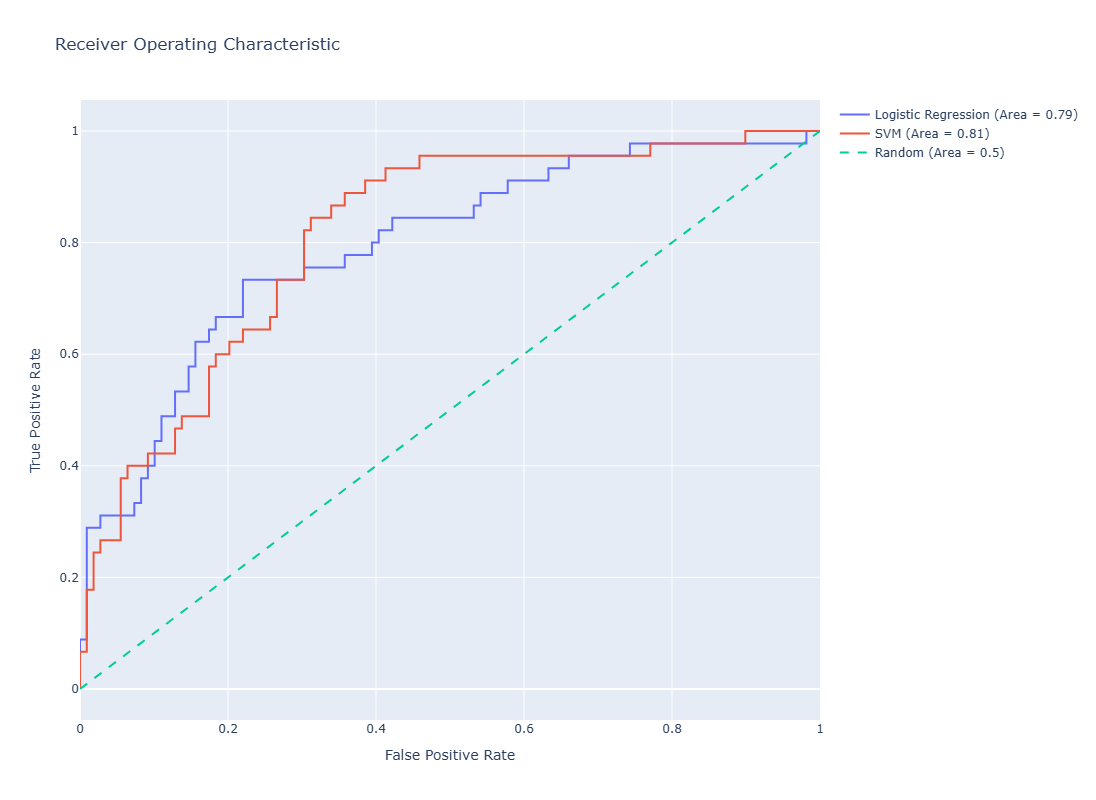

In [12]:
import numpy as np
import plotly.graph_objects as go
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.preprocessing import StandardScaler

# Assuming that X_train, X_test, y_train, y_test are already defined

# SVM requires feature scaling for better performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression model
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
lr_scores = lr_model.predict_proba(X_test)[:,1]

# SVM model
svm_model = SVC(probability=True)
svm_model.fit(X_train_scaled, y_train)
svm_scores = svm_model.predict_proba(X_test_scaled)[:,1]

# Generate ROC curve data for logistic regression model
lr_fpr, lr_tpr, lr_thresholds = roc_curve(y_test, lr_scores)
lr_auc = roc_auc_score(y_test, lr_scores)

# Generate ROC curve data for SVM model
svm_fpr, svm_tpr, svm_thresholds = roc_curve(y_test, svm_scores)
svm_auc = roc_auc_score(y_test, svm_scores)

# Generate a trace for the Logistic Regression ROC curve
trace0 = go.Scatter(
    x=lr_fpr,
    y=lr_tpr,
    mode='lines',
    name=f'Logistic Regression (Area = {lr_auc:.2f})'
)

# Generate a trace for the SVM ROC curve
trace1 = go.Scatter(
    x=svm_fpr,
    y=svm_tpr,
    mode='lines',
    name=f'SVM (Area = {svm_auc:.2f})'
)

# Diagonal line
trace2 = go.Scatter(
    x=[0, 1],
    y=[0, 1],
    mode='lines',
    name='Random (Area = 0.5)',
    line=dict(dash='dash')
)

data = [trace0, trace1, trace2]

# Define layout with square aspect ratio
layout = go.Layout(
    title='Receiver Operating Characteristic',
    xaxis=dict(title='False Positive Rate'),
    yaxis=dict(title='True Positive Rate'),
    autosize=False,
    width=800,
    height=800,
    showlegend=True
)

# Define figure and add data
fig = go.Figure(data=data, layout=layout)

# Show figure
fig.show()
